## 4.3 앙상블 학습 개요

**앙상블(Ensemble)이란?**

여러 모델을 합쳐서 하나의 모델보다 더 좋은 예측을 만드는 방법이다.
혼자보다 여럿이 낫다는 개념이라고 보면 된다.

### Voting Classifier

**Voting Classifier란?**

여러 모델이 각자 예측한 결과를 모아서 '투표'로 최종 결정하는 방식이다.

- **Hard Voting**: 각 모델이 예측한 클래스 중 가장 많이 나온 걸 선택
- **Soft Voting**: 각 모델의 확률을 평균 내서 가장 높은 걸 선택 (보통 더 성능이 좋음)

In [1]:
import pandas as pd

# 앙상블, 로지스틱 회귀, KNN, 데이터셋, 분할, 평가 도구 불러오기
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 유방암 데이터셋 불러오기 (악성/양성 분류 문제)
cancer = load_breast_cancer()

# 넘파이 배열을 DataFrame으로 변환해서 보기 좋게 만들기
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)  # 상위 3행만 출력해서 데이터 구조 확인


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [2]:
# 개별 모델은 로지스틱 회귀와 KNN 임. 
lr_clf = LogisticRegression(solver='liblinear')  # 로지스틱 회귀 모델 생성
knn_clf = KNeighborsClassifier(n_neighbors=8)    # KNN 모델 생성 (가장 가까운 8개 이웃 참고)

# 두 모델을 묶어 소프트 보팅 방식의 앙상블 모델 만들기
# estimators: 사용할 모델 목록을 (이름, 모델) 형태로 전달
# voting='soft': 각 모델의 확률을 평균 내서 최종 결정
vo_clf = VotingClassifier( estimators=[('LR',lr_clf),('KNN',knn_clf)] , voting='soft' )

# 데이터를 학습용 80%, 테스트용 20%로 나누기
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, 
                                                    test_size=0.2 , random_state= 156)

# VotingClassifier 학습/예측/평가. 
vo_clf.fit(X_train , y_train)           # 앙상블 모델 학습
pred = vo_clf.predict(X_test)           # 테스트 데이터로 예측
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

# 개별 모델의 학습/예측/평가 (앙상블과 비교하기 위해)
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train , y_train)   # 각 모델 학습
    pred = classifier.predict(X_test)   # 각 모델로 예측
    class_name= classifier.__class__.__name__  # 모델 이름 가져오기
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test , pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


**결과 해석**

보통 Voting 분류기의 정확도가 개별 모델보다 높게 나온다.
각 모델의 단점을 서로 보완하기 때문이다.

In [1]:
import os
path = r'C:\Users\hyoli\OneDrive\문서\대외활동\CUAI\human+activity+recognition+using+smartphones\UCI HAR Dataset'
print(os.listdir(path))

['human_activity', '__MACOSX']


In [3]:
import os
path = r'C:\Users\hyoli\OneDrive\문서\대외활동\CUAI\human+activity+recognition+using+smartphones\UCI HAR Dataset\human_activity'
print(os.listdir(path))

['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

BASE = r'C:\Users\hyoli\OneDrive\문서\대외활동\CUAI\human+activity+recognition+using+smartphones\UCI HAR Dataset\human_activity'

feature_name_df = pd.read_csv(BASE + r'\features.txt', sep='\s+',
                        header=None, names=['column_index','column_name'])

feature_name = feature_name_df.iloc[:, 1].values.tolist()
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [6]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()
#원본 데이터에 중복된 Feature 명으로 인하여 신규 버전의 Pandas에서 Duplicate name 에러를 발생.
#중복 feature명에 대해서 원본 feature 명에 '_1(또는2)'를 추가로 부여하는 함수인 get_new_feature_name_df() 생성

def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1]) 
                                                                                         if x[1] >0 else x[0] ,  axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

column_index    42
dtype: int64


In [8]:
import pandas as pd

BASE = r'C:\Users\hyoli\OneDrive\문서\대외활동\CUAI\human+activity+recognition+using+smartphones\UCI HAR Dataset\human_activity'

def get_human_dataset():
    
    # 각 데이터 파일들은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당.
    feature_name_df = pd.read_csv(BASE + r'\features.txt', sep='\s+',
                        header=None, names=['column_index','column_name'])
    
    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame생성. 
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # DataFrame에 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 학습 피처 데이터 셋과 테스트 피처 데이터을 DataFrame으로 로딩. 컬럼명은 feature_name 적용
    X_train = pd.read_csv(BASE + r'\train\X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv(BASE + r'\test\X_test.txt', sep='\s+', names=feature_name)
    
    # 학습 레이블과 테스트 레이블 데이터을 DataFrame으로 로딩하고 컬럼명은 action으로 부여
    y_train = pd.read_csv(BASE + r'\train\y_train.txt', sep='\s+', header=None, names=['action'])
    y_test = pd.read_csv(BASE + r'\test\y_test.txt', sep='\s+', header=None, names=['action'])
    
    # 로드된 학습/테스트용 DataFrame을 모두 반환 
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_human_dataset()

C:\Users\hyoli\AppData\Local\Temp\ipykernel_26376\1715241873.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if x[1] >0 else x[0] ,  axis=1)
C:\Users\hyoli\AppData\Local\Temp\ipykernel_26376\1715241873.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1])


## 4.4 Random Forest

**Random Forest란?**

결정 트리(Decision Tree) 여러 개를 합친 앙상블 모델이다.
각 트리가 **랜덤하게 선택된 피처와 데이터**로 학습하고, 그 결과를 합산해서 예측한다.

- 트리가 많을수록 성능이 안정되는 경향이 있다
- 과적합(overfitting)에 강하다는 장점이 있다

> 아래 코드는 결정트리 챕터에서 사용하는 human_activity 데이터셋을 활용한 예제로,
> 해당 챕터를 아직 학습하지 않아 해당 코드 작성 연습만 진행함. 결정트리 챕터부분 빼고 

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

# 결정 트리에서 사용한 get_human_dataset( )을 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# Random Forest 모델 생성 (기본값: 트리 100개)
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train , y_train)           # 모델 학습
pred = rf_clf.predict(X_test)           # 테스트 데이터로 예측
accuracy = accuracy_score(y_test , pred) # 정확도 계산
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9223


In [10]:
from sklearn.model_selection import GridSearchCV

# 시도해볼 하이퍼파라미터 조합 정의
# n_estimators: 트리 개수
# max_depth: 트리 최대 깊이 (깊을수록 복잡한 패턴 학습, 과적합 위험)
# min_samples_leaf: 리프 노드에 필요한 최소 샘플 수
# min_samples_split: 노드를 나누려면 필요한 최소 샘플 수
params = {
    'n_estimators':[100],
    'max_depth' : [6, 8, 10, 12], 
    'min_samples_leaf' : [8, 12, 18 ],
    'min_samples_split' : [8, 16, 20]
}
# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)  # n_jobs=-1: CPU 전부 사용
grid_cv = GridSearchCV(rf_clf , param_grid=params , cv=2, n_jobs=-1 )  # 모든 조합 탐색
grid_cv.fit(X_train , y_train)  # 학습 (시간이 오래 걸릴 수 있음)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)  # 가장 좋은 파라미터 출력
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))  # 그때의 정확도 출력

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9178


In [12]:
# GridSearchCV에서 찾은 최적 파라미터로 모델 다시 만들기
# n_estimators=300으로 트리 수를 더 늘려서 성능 안정화
rf_clf1 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=8, \
                                 min_samples_split=8, random_state=0)
rf_clf1.fit(X_train , y_train)   # 최적 파라미터로 학습
pred = rf_clf1.predict(X_test)   # 예측
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test , pred)))

예측 정확도: 0.9165


human_activity 관련 셀 전체에 결정트리 챕터 데이터라 코드 작성 연습만 함 

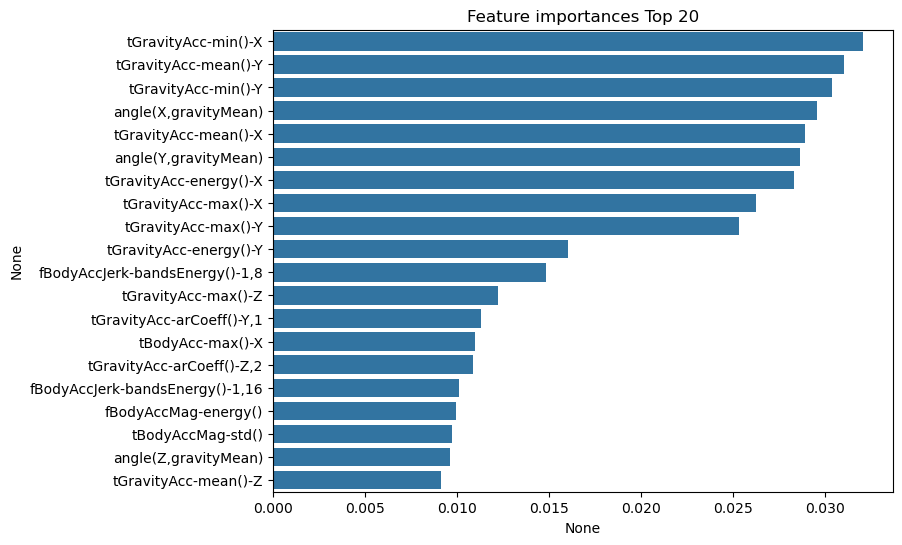

<Figure size 640x480 with 0 Axes>

In [13]:
%matplotlib inline  
# 주피터 노트북 안에 그래프 출력되도록 설정
import matplotlib.pyplot as plt
import seaborn as sns


# 각 피처의 중요도 값 가져오기 (0~1 사이 값, 합이 1)
ftr_importances_values = rf_clf1.feature_importances_

# 피처 이름을 인덱스로 하는 Series 만들기
ftr_importances = pd.Series(ftr_importances_values,index=X_train.columns)

# 중요도 높은 순으로 정렬 후 상위 20개만 선택
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20 , y = ftr_top20.index)  # 가로 막대 그래프로 시각화
fig1 = plt.gcf()   # 현재 그래프 객체 가져오기
plt.show()
plt.draw()
fig1.savefig('rf_feature_importances_top20.tif', format='tif', dpi=300, bbox_inches='tight')  # 파일로 저장

**Feature Importance(피처 중요도)란?**

Random Forest에서 각 피처가 예측에 얼마나 기여했는지를 수치로 나타낸 것이다.
값이 클수록 그 피처가 모델 예측에 중요한 역할을 했다는 뜻이다.

어떤 피처가 중요한지 파악하면 불필요한 피처를 제거하는 데 활용할 수 있다.